In [1]:
#Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import pandas as pd

# === Step 1: Load MNIST Dataset ===
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
        return images / 255.0

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        _, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels
 # Students can experiment to modify number of Train
X_train = load_mnist_images("train-images.idx3-ubyte__")[:500]
y_train = load_mnist_labels("train-labels.idx1-ubyte__")[:500]
X_test = load_mnist_images("t10k-images.idx3-ubyte__")[:200]
y_test = load_mnist_labels("t10k-labels.idx1-ubyte__")[:200]

In [2]:
# === Step 2: Activation Functions (Refer to Eq. 6.14 - 6.18) ===
def relu(x): return np.maximum(0, x)
def tanh(x): return np.tanh(x)
def softplus(x): return np.log(1 + np.exp(x))
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)

def one_hot(y, num_classes=10): # Refer to Equation 6.36
    return np.eye(num_classes)[y]
def cross_entropy(y_pred, y_true): # Refer to Equation 6.36
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    return -np.sum(y_true * np.log(y_pred)) / y_pred.shape[0]
def softmax(a): # Refer to Equation 6.37
    exp_a = np.exp(a - np.max(a, axis=1, keepdims=True))
    return exp_a / np.sum(exp_a, axis=1, keepdims=True)

def forward_pass(X, weights, activations): # Forward Pass (Eq. 6.19) ===
    A = X
    for W, act in zip(weights, activations):
        Z = A @ W
        A = act(Z)
    return A

In [3]:
# === Step 3: Training Loop === # Students can experiment to modify
np.random.seed(42)

def train(input_size=784, hidden1=64, hidden2=16, output_size=10, epochs=1):
    best_loss = float('inf')
    best_weights = None

    y_train_oh = one_hot(y_train, num_classes=output_size)
    y_test_oh = one_hot(y_test, num_classes=output_size)

    for epoch in range(epochs):
        # TODO: Randomly initialize weights for each layer
        W1 = np.random.randn(input_size, hidden1) * 0.01
        W2 = np.random.randn(hidden1, hidden2) * 0.01
        W3 = np.random.randn(hidden2, output_size) * 0.01

        weights = [W1, W2, W3]
        activations = [relu, relu, softmax]  # Students can experiment to modify

        y_pred_train = forward_pass(X_train, weights, activations)
        loss = cross_entropy(y_pred_train, y_train_oh)

        if loss < best_loss:
            best_loss = loss
            best_weights = weights

    y_pred_test = forward_pass(X_test, best_weights, activations)
    y_pred_labels = np.argmax(y_pred_test, axis=1)

    return y_pred_test, y_pred_labels, y_test_oh

In [4]:
# === Step 4: Evaluation Metrics (Confusion Matrix, ROC, etc) ===
def compute_confusion_matrix(y_true, y_pred, num_classes=10): 
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

# === ROC Curve ===
def compute_roc(y_true_oh, y_pred_proba):  
    fpr, tpr = {}, {}
    for i in range(y_true_oh.shape[1]):
        probs = y_pred_proba[:, i]
        true_labels = y_true_oh[:, i]

        sort_idx = np.argsort(probs)[::-1]
        probs = probs[sort_idx]
        true_labels = true_labels[sort_idx]

        tps = np.cumsum(true_labels)
        fps = np.cumsum(1 - true_labels)

        fpr[i] = fps / fps[-1] if fps[-1] > 0 else np.zeros_like(fps)
        tpr[i] = tps / tps[-1] if tps[-1] > 0 else np.zeros_like(tps)
    return fpr, tpr

# === Classification Report === Print TP, FP, FN, TN, precision, recall, f1, accuracy
def compute_metrics(cm): 
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    precision = np.divide(TP, TP + FP, out=np.zeros_like(TP, dtype=float), where=(TP + FP) != 0)
    recall = np.divide(TP, TP + FN, out=np.zeros_like(TP, dtype=float), where=(TP + FN) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision, dtype=float), where=(precision + recall) != 0)
    accuracy = np.sum(TP) / np.sum(cm)
    return TP, FP, FN, TN, precision, recall, f1, accuracy

=== Classification Report ===


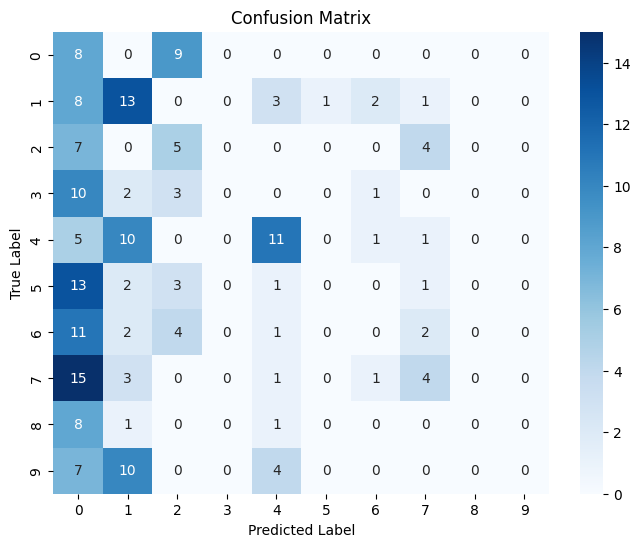

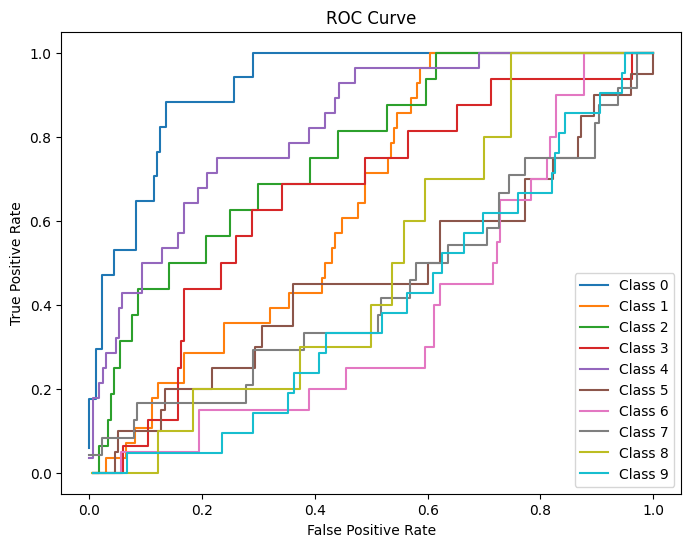

Overall Accuracy: 0.2050

Class  | TP   | FP   | FN   | TN   | Precision | Recall | F1-Score
---------------------------------------------------------------------------
0      | 8    | 84   | 9    | 99   | 0.0870    | 0.4706 | 0.1468
1      | 13   | 30   | 15   | 142  | 0.3023    | 0.4643 | 0.3662
2      | 5    | 19   | 11   | 165  | 0.2083    | 0.3125 | 0.2500
3      | 0    | 0    | 16   | 184  | 0.0000    | 0.0000 | 0.0000
4      | 11   | 11   | 17   | 161  | 0.5000    | 0.3929 | 0.4400
5      | 0    | 1    | 20   | 179  | 0.0000    | 0.0000 | 0.0000
6      | 0    | 5    | 20   | 175  | 0.0000    | 0.0000 | 0.0000
7      | 4    | 9    | 20   | 167  | 0.3077    | 0.1667 | 0.2162
8      | 0    | 0    | 10   | 190  | 0.0000    | 0.0000 | 0.0000
9      | 0    | 0    | 21   | 179  | 0.0000    | 0.0000 | 0.0000


In [9]:
y_pred_test, y_pred_labels, y_test_oh = train(
    input_size=784, hidden1=1024, hidden2=8, output_size=10, epochs=100
)

cm = compute_confusion_matrix(y_test, y_pred_labels)
fpr, tpr = compute_roc(y_test_oh, y_pred_test)
TP, FP, FN, TN, precision, recall, f1, accuracy = compute_metrics(cm)

print("=== Classification Report ===")

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i}')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision, Recall, F1, Overall Accuracy
print(f"Overall Accuracy: {accuracy:.4f}\n")
print(f"{'Class':<6} | {'TP':<4} | {'FP':<4} | {'FN':<4} | {'TN':<4} | {'Precision':<9} | {'Recall':<6} | {'F1-Score'}")
print("-" * 75)
for i in range(10):
    print(f"{i:<6} | {TP[i]:<4} | {FP[i]:<4} | {FN[i]:<4} | {TN[i]:<4} | {precision[i]:<9.4f} | {recall[i]:<6.4f} | {f1[i]:.4f}")

In [8]:
hidden1_candidates = [64, 128, 256, 512, 1024, 2048]
hidden2_candidates = [8, 16, 32, 64]  # 可自行增減
epoch_candidates = [1, 10, 50, 100]      # 新增：不同 epoch 組合
n_trials = 10

results = []
best_mean_acc = -np.inf
best_config = None
best_artifacts = None  # 存最佳組合下表現最好的一次結果

for ep in epoch_candidates:
    for h1 in hidden1_candidates:
        for h2 in hidden2_candidates:
            acc_list = []
            best_acc_this_combo = -np.inf
            best_run_this_combo = None

            for _ in range(n_trials):
                y_pred_test_i, y_pred_labels_i, y_test_oh_i = train(
                    input_size=784, hidden1=h1, hidden2=h2, output_size=10, epochs=ep
                )

                cm_i = compute_confusion_matrix(y_test, y_pred_labels_i)
                TP_i, FP_i, FN_i, TN_i, precision_i, recall_i, f1_i, accuracy_i = compute_metrics(cm_i)

                acc_list.append(float(accuracy_i))

                if accuracy_i > best_acc_this_combo:
                    best_acc_this_combo = accuracy_i
                    best_run_this_combo = (
                        y_pred_test_i, y_pred_labels_i, y_test_oh_i, cm_i,
                        TP_i, FP_i, FN_i, TN_i, precision_i, recall_i, f1_i, accuracy_i
                    )

            mean_acc = float(np.mean(acc_list))
            std_acc = float(np.std(acc_list))

            results.append({
                "epochs": ep,
                "hidden1": h1,
                "hidden2": h2,
                "mean_accuracy": mean_acc,
                "std_accuracy": std_acc,
                "best_single_run_accuracy": float(best_acc_this_combo)
            })

            print(
                f"ep={ep:<2} h1={h1:<4} h2={h2:<3} | "
                f"mean acc={mean_acc:.4f} ± {std_acc:.4f} | best single={best_acc_this_combo:.4f}"
            )

            if mean_acc > best_mean_acc:
                best_mean_acc = mean_acc
                best_config = {"epochs": ep, "hidden1": h1, "hidden2": h2}
                best_artifacts = best_run_this_combo

# 回寫最佳組合的最佳單次結果到常用變數
(
    y_pred_test, y_pred_labels, y_test_oh, cm,
    TP, FP, FN, TN, precision, recall, f1, accuracy
) = best_artifacts

results_df = (
    pd.DataFrame(results)
    .sort_values(["mean_accuracy", "best_single_run_accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("\n=== 排名（依 n_trials 次平均 accuracy）===")
display(results_df)

print(
    f"\n最佳設定: epochs={best_config['epochs']}, h1={best_config['hidden1']}, h2={best_config['hidden2']} "
    f"| 平均 accuracy={best_mean_acc:.4f} | 該設定最佳單次 accuracy={accuracy:.4f}"
)

ep=1  h1=64   h2=8   | mean acc=0.0990 ± 0.0250 | best single=0.1300
ep=1  h1=64   h2=16  | mean acc=0.1015 ± 0.0436 | best single=0.2000
ep=1  h1=64   h2=32  | mean acc=0.0895 ± 0.0288 | best single=0.1350
ep=1  h1=64   h2=64  | mean acc=0.1160 ± 0.0513 | best single=0.2200
ep=1  h1=128  h2=8   | mean acc=0.1030 ± 0.0240 | best single=0.1500
ep=1  h1=128  h2=16  | mean acc=0.1060 ± 0.0236 | best single=0.1300
ep=1  h1=128  h2=32  | mean acc=0.1060 ± 0.0476 | best single=0.2200
ep=1  h1=128  h2=64  | mean acc=0.0930 ± 0.0279 | best single=0.1400
ep=1  h1=256  h2=8   | mean acc=0.1110 ± 0.0296 | best single=0.1700
ep=1  h1=256  h2=16  | mean acc=0.1005 ± 0.0272 | best single=0.1450
ep=1  h1=256  h2=32  | mean acc=0.1060 ± 0.0275 | best single=0.1600
ep=1  h1=256  h2=64  | mean acc=0.1015 ± 0.0404 | best single=0.1900
ep=1  h1=512  h2=8   | mean acc=0.0910 ± 0.0284 | best single=0.1550
ep=1  h1=512  h2=16  | mean acc=0.1130 ± 0.0315 | best single=0.1800
ep=1  h1=512  h2=32  | mean acc=0.

,epochs,hidden1,hidden2,mean_accuracy,std_accuracy,best_single_run_accuracy
0,100,1024,8,0.1530,0.045782,0.215
1,50,128,32,0.1500,0.040187,0.235
2,100,256,32,0.1445,0.041860,0.225
3,50,2048,32,0.1435,0.019242,0.165
4,100,2048,64,0.1410,0.040175,0.235
...,...,...,...,...,...,...
91,1,1024,32,0.0945,0.028236,0.140
92,1,128,64,0.0930,0.027857,0.140
93,1,512,8,0.0910,0.028443,0.155
94,1,64,32,0.0895,0.028849,0.135



最佳設定: epochs=100, h1=1024, h2=8 | 平均 accuracy=0.1530 | 該設定最佳單次 accuracy=0.2150
